In [1]:
# Öğrenme aşamasında Keras, Production aşamasında ise Tensorflow ya da PyTorch kullanmalıyız

In [2]:
import torch                                # PyTorch kütüphanesi
import torch.nn as nn                       # PyTorch içerisindeki neural networkü aktardık
import torch.optim as optim                 # PyTorch içerisindeki Optimization algoritması olan Gradient Descent'i aktardık
import torchvision                          # Pytorch içerisindeki görüntü işleme modülü için
import torchvision.transforms as transforms # Pytorch içerisindeki görüntü işleme ile ilgili preprocessing aşamalarını gerçekleştirmek için
from torch.utils.data import DataLoader     # Verisetini okumak için

import matplotlib.pyplot as plt
import numpy as np

import os
import shutil

In [3]:
# device check
# eğer bilgisayarımızda cuda kuruluysa ve ekran kartımız varsa orada, değilse işlemcide yap bu işlemleri diyoruz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

In [4]:
device # benim bilgisayarımda ekran kartı olmadığından dolayı işlemlerimizi işlemcimizde yapmaya devam edicez. bu da işlemlerimizi daha yavaş yapmamıza sebep olck

device(type='cpu')

In [5]:
# load data with PyTorch with kaggle's dataset

def get_data_loaders(batch_size=64):
    
    source_dir = "/kaggle/input/cifar10"
    working_dir = "/kaggle/working/data"
    
    root_dir = os.path.join(working_dir, "cifar10")
    expected_subdir = os.path.join(root_dir, "cifar-10-batches-py")

    if not os.path.exists(expected_subdir):
        os.makedirs(expected_subdir, exist_ok=True)
        # Veri dosyalarını /kaggle/input'tan alıp, /kaggle/working'deki yeni yapıya kopyala
        for filename in os.listdir(source_dir):
            if not filename.startswith('.'):
                shutil.copy(os.path.join(source_dir, filename), expected_subdir)
    
    # ----------------------------------------------------------------------
    
    # preprocessing
    transform = transforms.Compose([
        transforms.ToTensor(),                                 # Görüntüyü tensore çevir. tensor aynı array gibi bir veritipi. pytorchta verinin işlenebilmesi için, yani neural networkümüzün çalışabilmesi için gerekli olan veri formatı Tensor'dür. Bu sebeple şimdi veriyi tensor formatında yükleyeceğiz
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # rgb kanallarını normalize edeceğimiz için 3 tane mean ve 3 tane standart sapma girdik
    ])


    train_set = torchvision.datasets.CIFAR10(
        root=root_dir, 
        train=True, 
        download=False, # İndirme yapma
        transform=transform
    )
    
    test_set = torchvision.datasets.CIFAR10(
        root=root_dir, 
        train=False, 
        download=False, # İndirme yapma
        transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_set, 
        batch_size=batch_size, 
        shuffle=True # Eğitim verisinde karıştırma yap
    )
    
    test_loader = torch.utils.data.DataLoader(
        test_set, 
        batch_size=batch_size, 
        shuffle=False # Test verisinde karıştırma gerekmez
    )

    return train_loader, test_loader

train_loader, test_loader = get_data_loaders()

print(f"Toplam Eğitim Örneği (Batch Sayısı): {len(train_loader)}")
print(f"Toplam Eğitim Veri Sayısı: {len(train_loader.dataset)}")

Toplam Eğitim Örneği (Batch Sayısı): 782
Toplam Eğitim Veri Sayısı: 50000


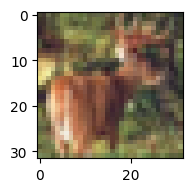

/tmp/ipykernel_13/1513780708.py:24: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, n, i+1)


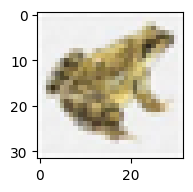

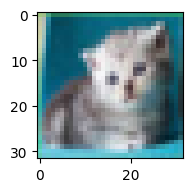

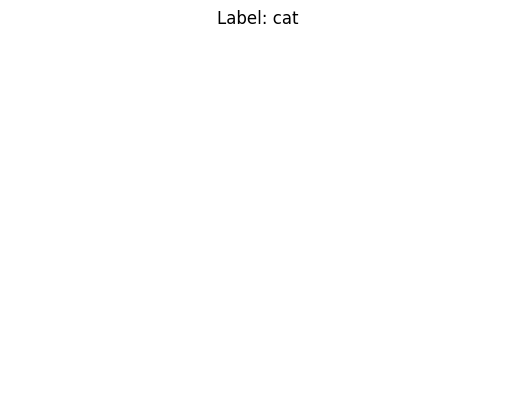

In [6]:
# verisetini gözlemle

CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img): # verileri normalize etmeden önceki hallerine geri döndürmemiz gerekiyor. 
    img = img * 0.5 + 0.5
    np_img = img.numpy() # numpy veritipine çeviriyoruz 
    plt.imshow(np.transpose(np_img, (1,2,0)))
    plt.show()

def get_sample_images(train_loader):
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    return images, labels

def visualize(n): # ilk bu fonksiyonu yazdık, sonra diğerlerini
    train_loader, test_loader = get_data_loaders()

    images, labels = get_sample_images(train_loader)

    plt.figure()

    for i in range(n):
        plt.subplot(1, n, i+1)
        imshow(images[i])
        plt.title(f"Label: {CLASSES[labels[i].item()]}")
        plt.axis("off")
    plt.show()

visualize(3)

In [7]:
# build CNN

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__() # pytorch'da neural network modülünden inherit edeceğinden 

        # convolution layer, activation function, pooling layer, dropout layer, fully connected layer(linear)

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 channel(RGB), 32 kernel, kernel boyutu 3x3, padding de olsun

        self.relu = nn.ReLU() # aktivasyon fonskiyonumuz relu olsun

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # stride=2 demek, 2'li 2'li kaysın matris üzerinde kernelimiz

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # önceki conv layer'ını 32 ile kapattıysak burayı 32 ile açmamız gerekir, aksi takdirde çalışmaz

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # stride=2 demek, 2'li 2'li kaysın matris üzerinde kernelimiz

        self.dropout = nn.Dropout(0.2) # %20'si kapalı olsun

        self.fc1 = nn.Linear(64*8*8, 128) # fully connected 1.layer'ın 64'ü bir önceki katmandan geliyor. 128 ise fully connected layer'da bulunan nöron saysı, istediğimizi verebilirdik. ensonki görüntülerimiz de 8x8 olacak

        self.fc2 = nn.Linear(128, 10)

        """
        Aslında hepsini hesaplayarak yaptık. Nasıl?
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) burada görüntümüzün 32x32x3 olduğunu söyledik.
        sonra buna self.pool = nn.MaxPool2d(kernel_size=2, stride=2) uygulayınca 32 oldu sana 16(git hesapla)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) sonra bu 16'ya conv uyguladık tekrar ve boyutu değişmedi hala 16
        sonrasında 1 pooling daha ve boyut 16'dan 8'e düştü.

        şimdi sıra bunları forward'da birbirine bağlamak
        """

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8) # flatten yapıyoruz
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# lost ve optimizer tanımlama
define_loss_and_optimizer = lambda model:(
    nn.CrossEntropyLoss(),
    optim.SGD(model.parameters(), lr=0.001, momentum=0.9) # stochastic gradient descent optimizer algoritması
)

model = CNN()

define_loss_and_optimizer(model)

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     momentum: 0.9
     nesterov: False
     weight_decay: 0
 ))

Epoch: 1/10, Loss: 2.04268
Epoch: 2/10, Loss: 1.69571
Epoch: 3/10, Loss: 1.50204
Epoch: 4/10, Loss: 1.39102
Epoch: 5/10, Loss: 1.31627
Epoch: 6/10, Loss: 1.25505
Epoch: 7/10, Loss: 1.20513
Epoch: 8/10, Loss: 1.15396
Epoch: 9/10, Loss: 1.10990
Epoch: 10/10, Loss: 1.06428


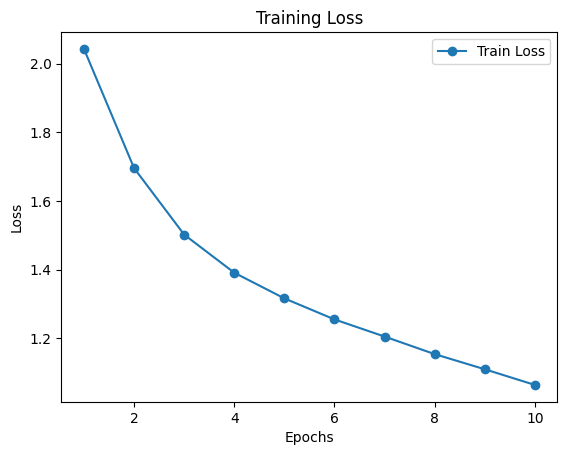

In [8]:
# Training

def train_model(model, train_loader, criterion, optimizer, epochs=5):
    
    model.train() # modelimizi eğitim moduna alalım
    
    train_losses = [] # loss değerlerini kaydetmek/saklamak için

    for epoch in range(epochs): # kaç epoch yapacaksak o sayıda işlemleri tekrarlayabilmek için for döngüsü
        total_loss = 0 # toplam loss değerini saklamak için
        for images, labels in train_loader: # tüm eğitim verisetini saklamak içindir bu for döngüsü
            images, labels = images.to(device), labels.to(device) # bunları cihazımıza gönderiyoruz

            optimizer.zero_grad() # optimizerımızın gradianlarını sıfırlıyoruz. yani ağırlıkları sıfırlayarak başlıyoruz

            outputs = model(images) # modelimize imageları verip sonuçları outputa kaydediyoruz. yani forward propagation yapıyoruz aslında

            loss = criterion(outputs, labels) # outputlarımızla labellarımızı karşılaştır, yani loss değerini hesapla

            loss.backward() # forward ve loss'u hallettikten sonra backward propagation yapıyoruz

            optimizer.step() # öğrenme(learning). update weights(ağırlıkları güncelle)

            total_loss += loss.item()

        avg_loss = total_loss/len(train_loader) # ortalama loss hesaplama
        train_losses.append(avg_loss)
        print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.5f}")

    # loss grafiği
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker="o", linestyle="-", label="Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.show()

train_loader, test_loader = get_data_loaders()
model = CNN().to(device)
criterion, optimizer = define_loss_and_optimizer(model)
train_model(model, train_loader, criterion, optimizer, epochs=10)

In [9]:
def test_model(model, test_loader, dataset_type): # bu da modeli test etmek için olan fonksiyon
    model.eval() # değerlendirilme modunu aktif hale getiriyor

    correct = 0 # doğru tahmin sayacı

    total = 0 # toplam veri sayacı

    with torch.no_grad(): # gradyan hesaplamasını kapat
        for images, labels in test_loader: # test verisetini kullanarak değerlendirme yapalım
            images, labels = images.to(device), labels.to(device)
    
            outputs = model(images) # prediction
    
            _, predicted = torch.max(outputs, 1) 
            # en yüksek olasılıklı sınıfı seç. _, ifadesinin sebebi, bize en yüksek olanı ver, diğeriyle ilgilenmiyoruz diyoruz
            # çünkü bize hem değerleri hem de indexlerini veriyor, o sebeple diğeriyle ilgilenmiyoruz diyoruz
    
            total += labels.size(0) # toplam veri sayısı
    
            correct += (predicted == labels).sum().item() # doğru tahmin sayar
    print(f"{dataset_type} accuracy: {100*(correct)/total}%")

Epoch: 1/5, Loss: 2.06404
Epoch: 2/5, Loss: 1.73402
Epoch: 3/5, Loss: 1.55310
Epoch: 4/5, Loss: 1.44505
Epoch: 5/5, Loss: 1.35971


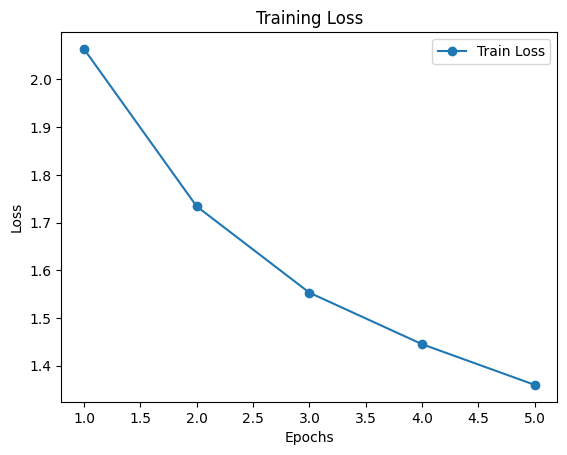

test accuracy: 52.51%
train accuracy: 52.872%


In [10]:
if __name__=="__main__":
    
    # verisetini yükleme
    train_loader, test_loader = get_data_loaders() 

    # training
    model = CNN().to(device)
    criterion, optimizer = define_loss_and_optimizer(model)
    train_model(model, train_loader, criterion, optimizer)

    # test
    test_model(model, test_loader, dataset_type="test")
    test_model(model, train_loader, dataset_type="train")